<a href="https://colab.research.google.com/github/Siya-Tambe/Major-Project-_Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
df.shape

(4000, 28)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [10]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [11]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
3995,False
3996,False
3997,False
3998,False


In [12]:
df["Rainfall_mm"]=df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"]=df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())

df["Yield_Tonnes_Ha"]=df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


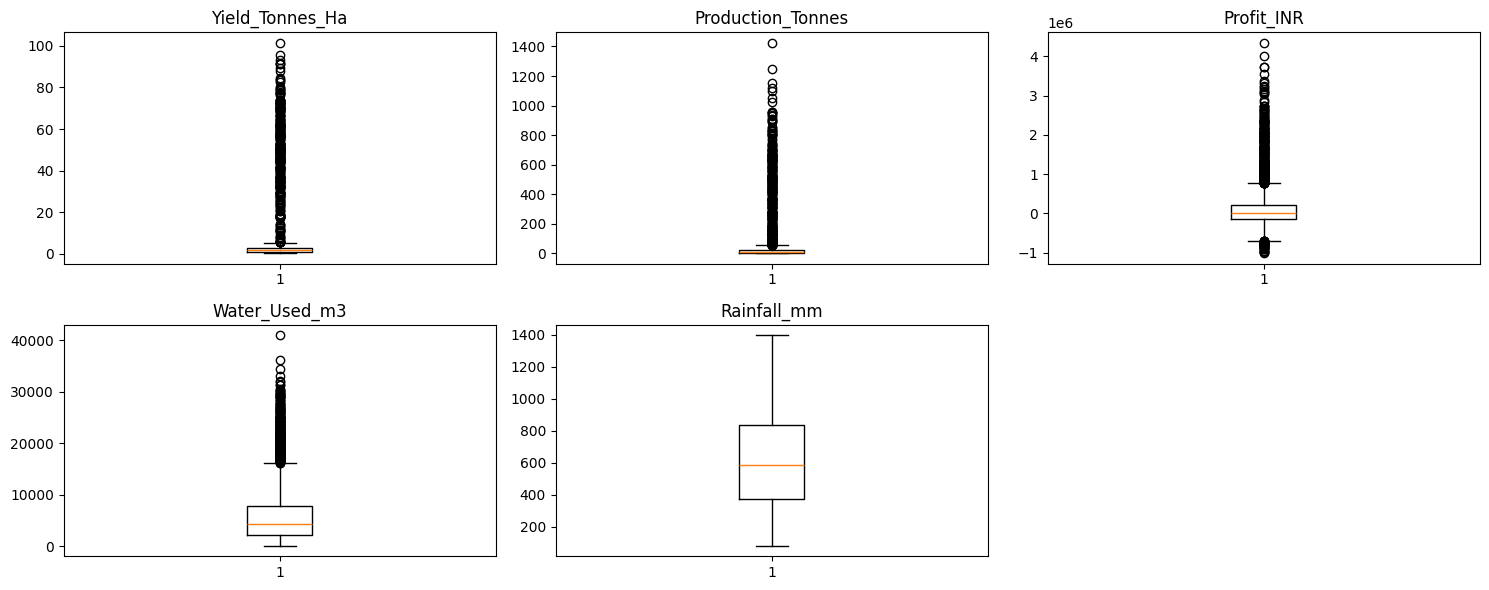

In [13]:
cols_to_check = ['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Water_Used_m3','Rainfall_mm']

plt.figure(figsize=(15,6))
for i, col in enumerate(cols_to_check, 1):
  plt.subplot(2,3,i)
  plt.boxplot(df[col].dropna())
  plt.title(col)
plt.tight_layout()
plt.show()

In [14]:
def count_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in cols_to_check:
    count, lower, upper = count_outliers_iqr(col)
    print(col, ":", count, "outliers | valid range:", round(lower,2), "to", round(upper,2))

Yield_Tonnes_Ha : 302 outliers | valid range: -1.62 to 5.5
Production_Tonnes : 333 outliers | valid range: -23.98 to 53.36
Profit_INR : 404 outliers | valid range: -696111.0 to 763567.0
Water_Used_m3 : 276 outliers | valid range: -6072.75 to 16171.25
Rainfall_mm : 0 outliers | valid range: -319.02 to 1522.57


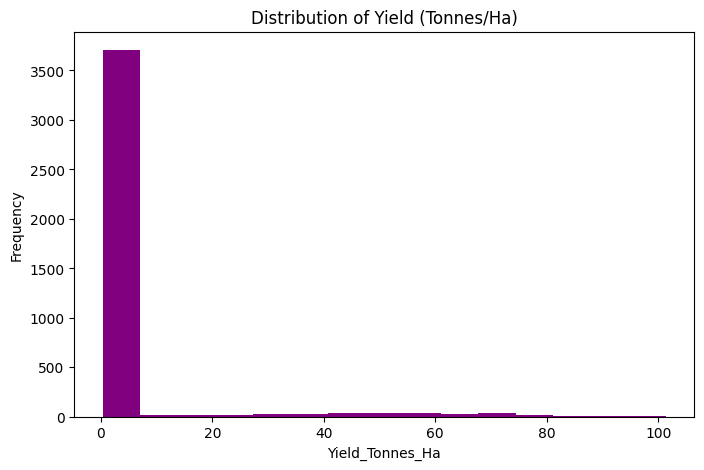

In [15]:
# Histogram for Yield_Tonnes_Ha column

plt.figure(figsize=(8,5))
plt.hist(df['Yield_Tonnes_Ha'], bins = 15, color = 'purple')
plt.title('Distribution of Yield (Tonnes/Ha)')
plt.xlabel('Yield_Tonnes_Ha')
plt.ylabel('Frequency')
plt.show()

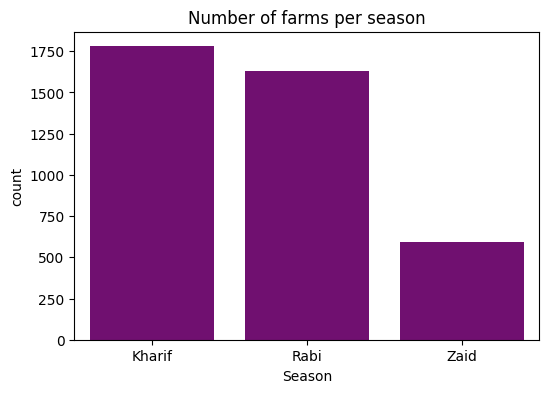

In [16]:
# Categorical : Count plot for season
plt.figure(figsize=(6,4))
sns.countplot(x='Season',data=df, color = 'purple')
plt.title('Number of farms per season')
plt.show()

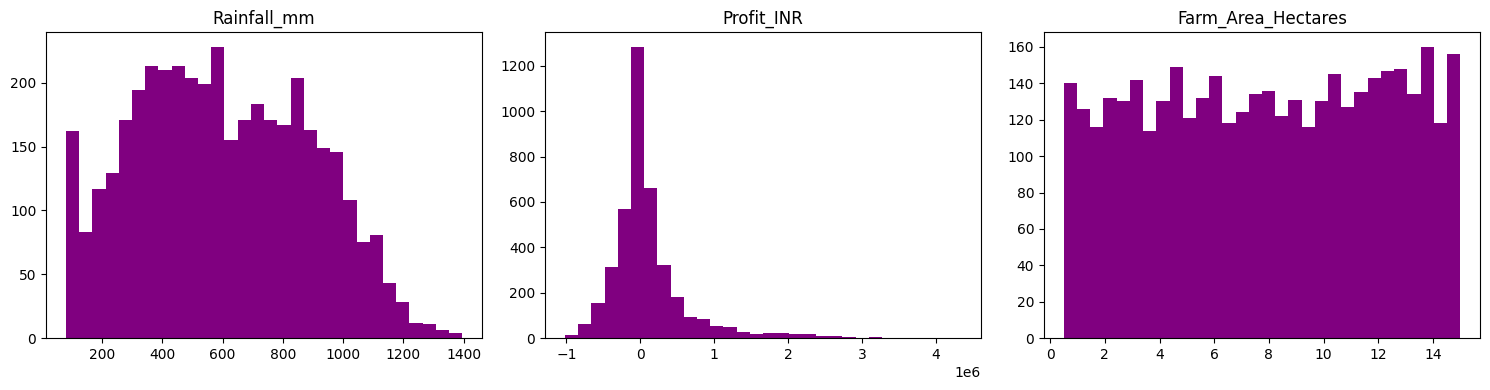

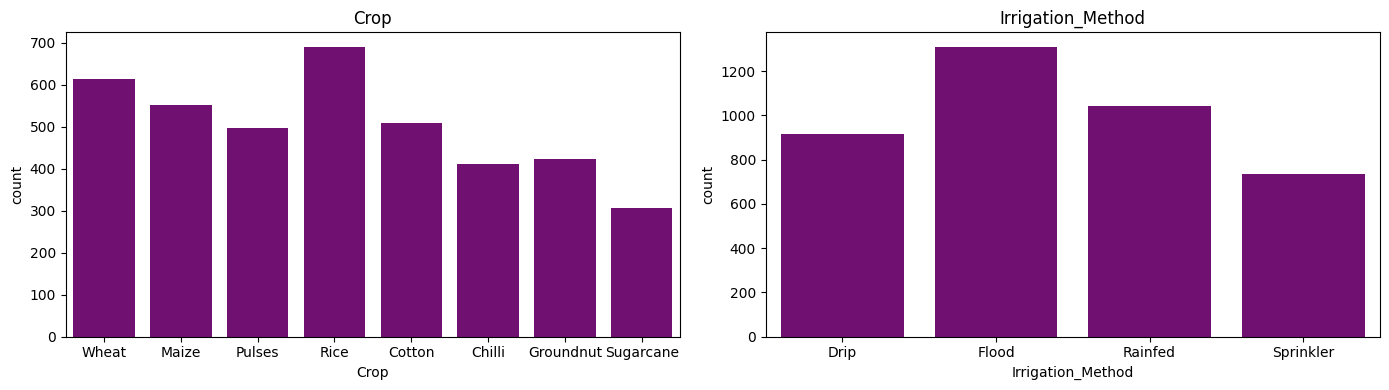

In [17]:
# Numeric columns - histograms
numeric_cols = ['Rainfall_mm','Profit_INR','Farm_Area_Hectares']

plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_cols, 1):
  plt.subplot(1, 3, i)
  plt.hist(df[col],bins=30, color='purple')
  plt.title(col)
plt.tight_layout()
plt.show()

# Categorical columns - count plots

cat_cols = ['Crop','Irrigation_Method']

plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols, 1):
  plt.subplot(1, 2, i)
  sns.countplot(x=col, data=df, color='purple')
  plt.title(col)
plt.tight_layout()
plt.show()


## Univariate Analysis Insights:
- Rainfall roughly normal distribution, no major skew
- Profit heavily right-skewed — most farms moderate profit, few very high earners
- Farm size uniformly distributed across dataset
- Rice is the most-grown crop; Flood irrigation is most common method

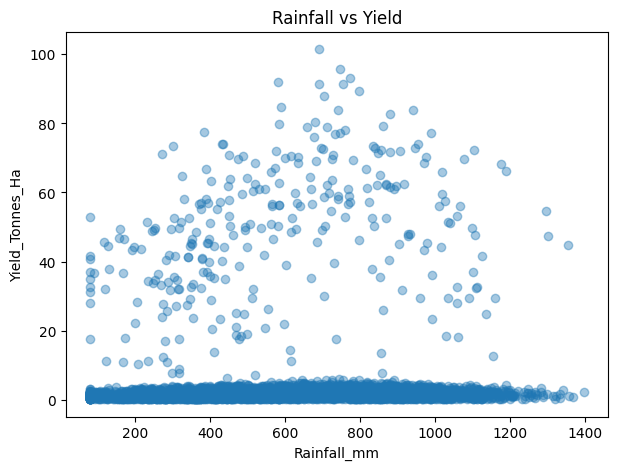

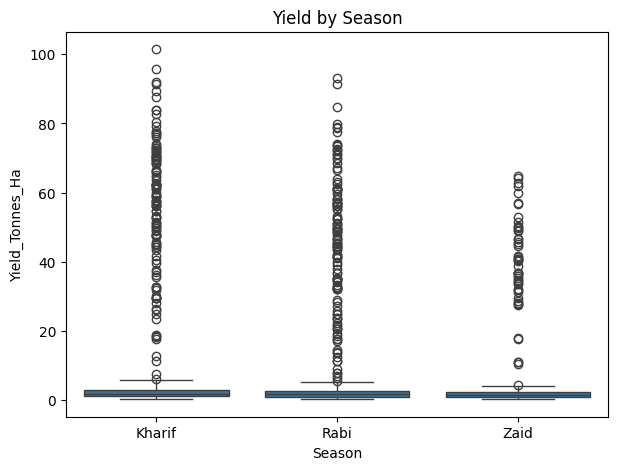

In [18]:
# 1. Numeric vs Numeric - Rainfall vs Yield
plt.figure(figsize=(7,5))
plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], alpha=0.4)
plt.xlabel('Rainfall_mm')
plt.ylabel('Yield_Tonnes_Ha')
plt.title('Rainfall vs Yield')
plt.show()

# 2. Categorical vs Numeric - Season vs Yield
plt.figure(figsize=(7,5))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)
plt.title('Yield by Season')
plt.show()

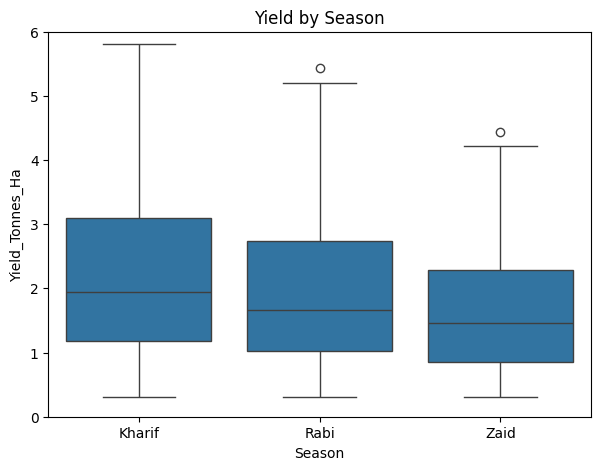

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)
plt.title('Yield by Season')
plt.ylim(0, 6)
plt.show()

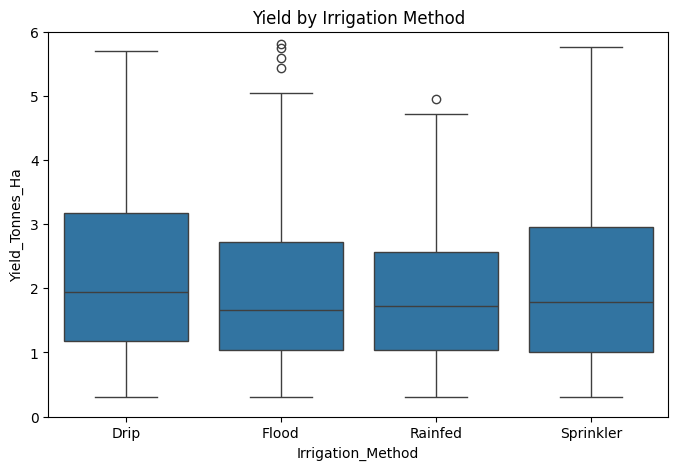

In [20]:
# Irrigation_Method vs Yield
plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Method', y='Yield_Tonnes_Ha', data=df)
plt.title('Yield by Irrigation Method')
plt.ylim(0,6)
plt.show()

## Bivariate Analysis Insights
- Rainfall vs Yield: top-performing farms cluster around 600-700mm rainfall —
  suggests an optimal rainfall zone for high yield
- Kharif season shows highest median yield and most consistency across farms
- Drip and Sprinkler irrigation methods outperform Flood and Rainfed in yield'''

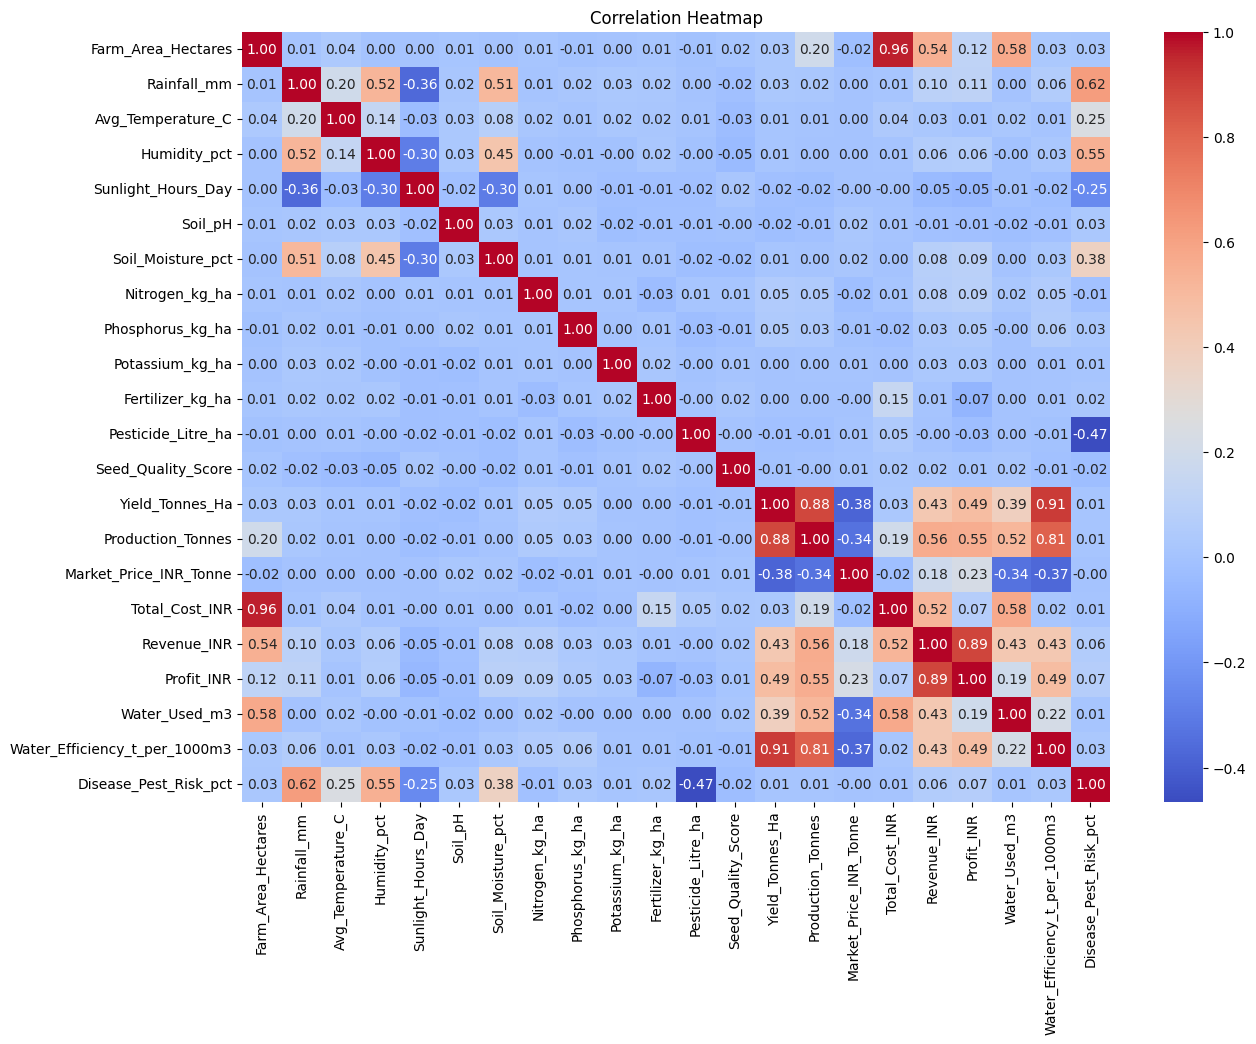

In [21]:
# Multivariate analysis - correlation heatmap
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Multivariate / Correlation Analysis Insights
- Farm area strongly drives total cost (0.96)
- Yield strongly correlates with water efficiency (0.91) and production (0.88)
- Revenue and Profit are strongly linked (0.89), as expected
- Higher rainfall is linked to higher disease/pest risk (0.62)
- Market price shows a negative correlation with yield/production —
  possibly reflecting supply-demand dynamics
- Surprisingly, individual input factors (fertilizer, pesticide, seed quality,
  N-P-K levels) show almost no linear correlation with yield — suggests yield
  is driven more by combined/interacting factors than any single input'''

In [22]:
seasonal_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR','Total_Cost_INR','Water_Used_m3','Disease_Pest_Risk_pct']].mean()
print(seasonal_summary)

        Yield_Tonnes_Ha     Profit_INR  Total_Cost_INR  Water_Used_m3  \
Season                                                                  
Kharif         5.628612  178914.647555   531804.408094    6102.201237   
Rabi           5.039435   87689.470191   513836.578365    5846.987093   
Zaid           4.641313  -24804.824916   543976.728956    6419.893939   

        Disease_Pest_Risk_pct  
Season                         
Kharif              54.467903  
Rabi                40.482114  
Zaid                38.216667  


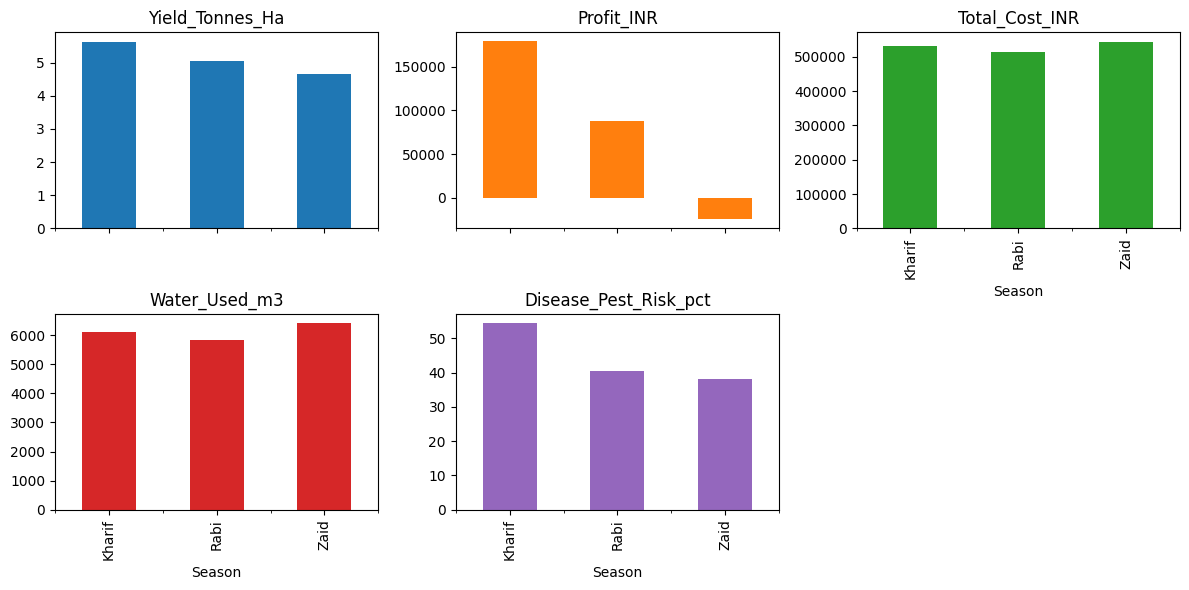

In [23]:
seasonal_summary.plot(kind='bar',figsize=(12,6),subplots=True, layout=(2,3),legend=False)
plt.tight_layout()
plt.show()

## Seasonal Comparison Insights:
- Kharif: highest yield & profit, but also highest disease/pest risk
- Rabi: most balanced — moderate yield, lowest cost, lowest water use
- Zaid: LOSS-MAKING on average (-₹24,804) despite highest cost and
  water usage — least efficient season overall
- This suggests Zaid season farming practices need review — either crop
  selection, resource allocation, or risk mitigation strategies.

## Student-Designed Analysis 1
 **State-wise most profitable state?**

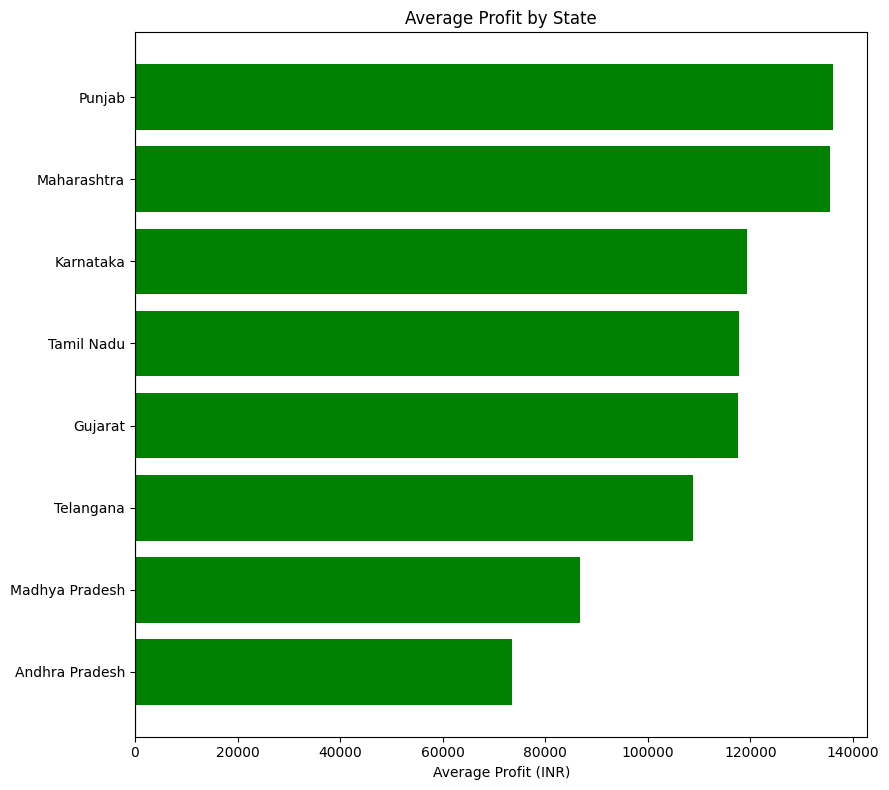

In [24]:

state_profit = df.groupby('State')['Profit_INR'].mean().sort_values()

colors = ['red' if x < 0 else 'green' for x in state_profit]

plt.figure(figsize=(9,8))
plt.barh(state_profit.index, state_profit.values, color=colors)
plt.xlabel('Average Profit (INR)')
plt.title('Average Profit by State')
plt.axvline(0, color='black', linewidth=0.8)  # zero line for reference
plt.tight_layout()
plt.show()

## Student Analysis 1
**State-wise Profitability**

Punjab, Maharashtra and Karnataka show the highest average profits.
Unlike the seasonal analysis, no state shows a net loss — confirming
that Zaid season's loss is a season-specific issue, not a regional one.

## Student-Designed Analysis 2
**Crop-wise most water efficient plant?**

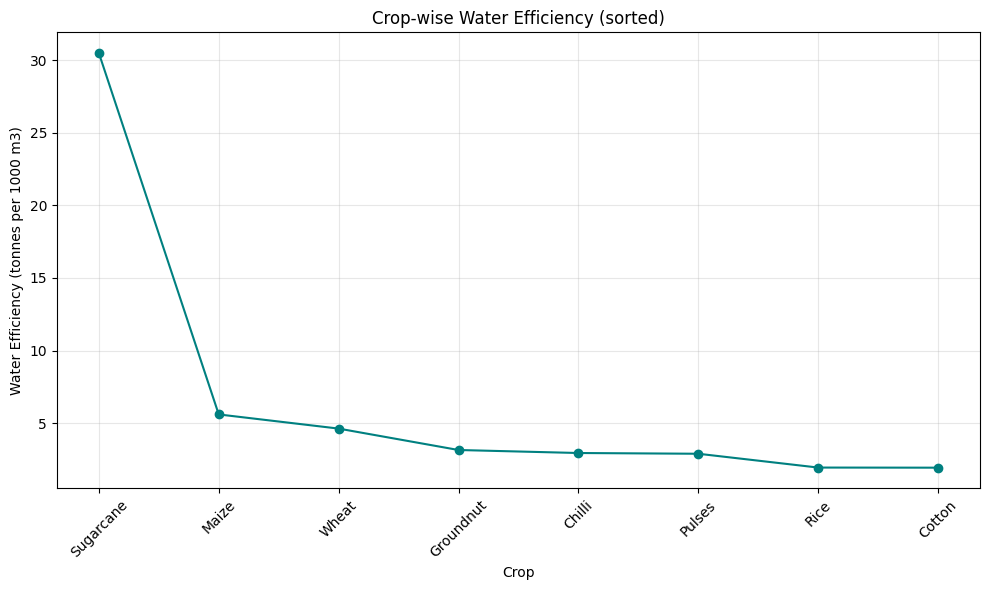

In [25]:
crop_efficiency = df.groupby('Crop')[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].mean().sort_values('Water_Efficiency_t_per_1000m3', ascending=False)

plt.figure(figsize=(10,6))
plt.plot(crop_efficiency.index, crop_efficiency['Water_Efficiency_t_per_1000m3'], marker='o', color='teal', label='Water Efficiency')
plt.xlabel('Crop')
plt.ylabel('Water Efficiency (tonnes per 1000 m3)')
plt.title('Crop-wise Water Efficiency (sorted)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Student Analysis 2
**Crop-wise Water Efficiency**

Sugarcane shows dramatically higher water efficiency (~30 t/1000m3) compared
to all other crops (2-6 t/1000m3 range). While Sugarcane is typically
considered water-intensive, its output-per-unit-water ratio is far superior —
likely because its high yield (tonnes) compensates for high water usage.
All other crops show relatively similar, low water efficiency.

## Student-Designed Analysis 3
Does higher disease/pest risk always lead to lower profit, or do some
farms manage to stay profitable despite high risk?

Disease_Risk_Category
Low        11074.303183
Medium    134915.393173
High       53314.631799
Name: Profit_INR, dtype: float64


/tmp/ipykernel_1635/2215270477.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_profit = df.groupby('Disease_Risk_Category')['Profit_INR'].mean()


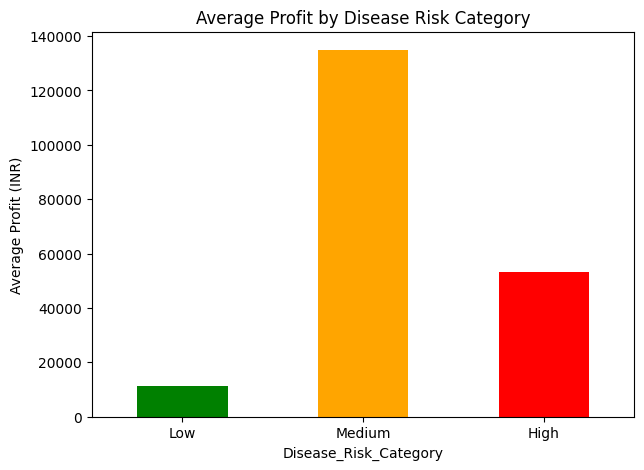

In [26]:
df['Disease_Risk_Category'] = pd.cut(df['Disease_Pest_Risk_pct'],
                                       bins=[0, 33, 66, 100],
                                       labels=['Low', 'Medium', 'High'])

risk_profit = df.groupby('Disease_Risk_Category')['Profit_INR'].mean()
print(risk_profit)

plt.figure(figsize=(7,5))
risk_profit.plot(kind='bar', color=['green','orange','red'])
plt.title('Average Profit by Disease Risk Category')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.show()

## Student-Designed Analysis 3
**Question: Does higher disease/pest risk always lead to lower profit?**

Answer: No — the relationship is non-linear. Medium-risk farms show the
highest average profit (~1.35L), while Low-risk farms show the lowest
(~10K), and High-risk farms fall in between (~52K). This suggests disease
risk alone doesn't determine profitability — other factors (farming intensity,
crop choice, resource investment) likely interact with it. Further analysis
would be needed to confirm the exact cause.


## Recommendations:
1. Farming practices in the Zaid season should be reviewed — cost-cutting
   measures or better crop selection could help avoid the observed losses.

2. Drip and Sprinkler irrigation methods should be promoted over Flood/Rainfed
   irrigation, given their association with better yield outcomes.

3. Since Kharif season shows both the highest yield/profit and the highest
   disease/pest risk, strengthening pest-control measures during this season
   could further improve profitability.

4. High water-efficiency crops like Sugarcane should be encouraged in regions
   facing water scarcity.
   
5. Since individual inputs (fertilizer, pesticide, NPK levels) show weak
   correlation with yield, farmers should focus on balanced, combined input
   strategies rather than increasing any single input in isolation.


## Limitations:
1. The Zaid season has a considerably smaller sample size compared to Kharif
   and Rabi (~600 vs ~1650-1800 records), so its findings may be less
   statistically reliable.

2. The non-linear relationship observed between disease risk and profit could
   not be fully explained using this dataset — additional data (e.g. farming
   intensity, input levels) would be needed to identify the underlying cause.

3. This analysis is based on correlation, not causation. For example, the
   association between Drip irrigation and higher yield does not guarantee
   that switching irrigation methods alone would improve results, as other
   interacting factors may be involved.
   
4. Outliers were retained rather than removed, since they were found to
   represent genuine high-performing farms. However, this may slightly skew
   some average-based comparisons.

##Conclusion:
This analysis shows that agricultural performance varies significantly across
seasons, irrigation methods, and regions. Kharif season emerged as the most
profitable and consistent, while Zaid season was found to be resource-inefficient
and operating at an average loss. Drip and Sprinkler irrigation methods, along
with balanced input strategies, appear to support better yield outcomes.
Sugarcane stood out as a highly water-efficient crop compared to others.
Overall, these findings can support evidence-based decisions around seasonal
planning and resource allocation, though further investigation is recommended —
particularly around the Zaid season's losses and the non-linear relationship
between disease risk and profit.